In [33]:
# Simple NLP Classification using NLTK + TF-IDF + Naive Bayes
# with K-Fold Cross-Validation and Hyperparameter Tuning


In [ ]:
import nltk
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def nltk_tokenizer(text):
    """Clean text and return a list of words."""

    text = text.lower()
    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word.isalpha() and word not in stop_words
    ]

    return words


In [ ]:
train_data = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))

print("Number of documents:", len(train_data.data))
print("Number of classes:", len(train_data.target_names))

print("\nClasses:")
print(train_data.target_names)

Number of documents: 11314
Number of classes: 20

Classes:
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']



 # Create the NLP + Naive Bayes pipeline

 Everything inside this pipeline is fitted only on the
 training portion of each cross-validation fold.

This prevents data leakage.

In [ ]:
pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(tokenizer=nltk_tokenizer, token_pattern=None)),
        ("nb", MultinomialNB()),
    ]
)

In [ ]:
# alpha controls smoothing in Naive Bayes.

# min_df removes words that occur in very few documents.

# max_features limits the total number of TF-IDF features.

parameters = {
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_features": [5000, 10000],
    "nb__alpha": [0.01, 0.1, 0.5, 1.0],
}


it means:

min_df- Keep a word only if it appears in at least 5 documents.

max_features - The features are ranked according to their overall frequency in the documents, and the highest-frequency features are retained up to max_features.

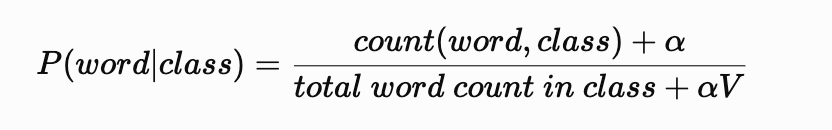

Alpha is a smoothing parameter that prevents zero probabilities and reduces the influence of very rare or unseen words on the classification decision.

Small alpha → less smoothing → more reliance on observed data

Large alpha → more smoothing → less sensitivity to rare/unseen words

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# =========================================================
# 8. Hyperparameter tuning using random Search
# =========================================================

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=parameters,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    n_iter=2,  # No. of hyperparameter combinations that are tried with EACH fold. Total no of trials = n_iter * n_splits !!!
    random_state=42,
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    train_data.data, train_data.target, test_size=0.20, random_state=1
)

print("\nTraining documents:", len(X_train))
print("Validation documents:", len(X_test))



Training documents: 9051
Validation documents: 2263


In [47]:
X_train[0]

"\nI don't know about that...I've used Photoshop 2.5 on both a 486dx-50 and a Quadra\n950...I'd say they are roughly equal.  If anything the 486 was faster."

In [49]:
y_train[0]

np.int64(1)

In [42]:
print("\nStarting 5-fold cross-validation...")
random_search.fit(X_train, y_train)


Starting 5-fold cross-validation...
Fitting 5 folds for each of 2 candidates, totalling 10 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(token_pattern=None,
                                                              tokenizer=<function nltk_tokenizer at 0x7bc38aac96c0>)),
                                             ('nb', MultinomialNB())]),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'nb__alpha': [0.01, 0.1, 0.5, 1.0],
                                        'tfidf__max_features': [5000, 10000],
                                        'tfidf__min_df': [1, 2, 5]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [43]:
print("\nBest parameters:")
print(random_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(random_search.best_score_, 4))


Best parameters:
{'tfidf__min_df': 5, 'tfidf__max_features': 5000, 'nb__alpha': 0.1}

Best cross-validation Macro F1:
0.6917


In [ ]:
best_model = random_search.best_estimator_  # Picks up the best model from the random search that uses the best hyperparameters found by RandomizedSearchCV!

y_pred = best_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print("\nFinal Test Results")
print("------------------")
print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Final Test Results
------------------
Accuracy: 0.6894
Macro F1: 0.6809

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.54      0.53      0.53        97
           comp.graphics       0.60      0.63      0.62       114
 comp.os.ms-windows.misc       0.65      0.63      0.64       112
comp.sys.ibm.pc.hardware       0.64      0.64      0.64       127
   comp.sys.mac.hardware       0.76      0.70      0.73       112
          comp.windows.x       0.69      0.79      0.74       115
            misc.forsale       0.80      0.67      0.73       124
               rec.autos       0.67      0.60      0.63       108
         rec.motorcycles       0.40      0.77      0.52        99
      rec.sport.baseball       0.80      0.83      0.81       113
        rec.sport.hockey       0.90      0.81      0.85       108
               sci.crypt       0.80      0.82      0.81       120
         sci.electronics       0.71      0.5

In [45]:
# Predict a new document
def classify_text(text):
    """Predict the topic of a new document."""

    probabilities = best_model.predict_proba([text])[0]

    best_class = np.argmax(probabilities)
    best_probability = probabilities[best_class]

    print("\nText:", text)
    print("Predicted topic:", data.target_names[best_class])
    print("Probability:", round(best_probability, 4))


In [ ]:
# Example predictions
classify_text("My first homemade PCB. My SMD soldering skills are not great.")

classify_text("New Toyota car launch has been delayed.")

classify_text("Particles from Earth can create water on the lunar surface.")



Text: My first homemade PCB. My SMD soldering skills are not great.
Predicted topic: rec.sport.hockey
Probability: 0.1473

Text: New Toyota car launch has been delayed.
Predicted topic: rec.autos
Probability: 0.7706

Text: Particles from Earth can create water on the lunar surface.
Predicted topic: sci.space
Probability: 0.7963
